# Conformalized Quantile Regression — AirPassengers Example

This notebook shows how to use `ConformalizedQuantileRegression` (CQR) on the
AirPassengers dataset (144 monthly observations, 1949–1960).

CQR differs from split conformal in how it forms intervals:

- **Split conformal** produces a symmetric interval around a *point* forecast,
  using the empirical quantile of absolute residuals as the half-width.
- **CQR** consumes the forecaster's *quantile* predictions directly and
  shrinks or widens that interval by a calibrated correction, so the
  underlying model's heteroscedasticity (varying width across horizon and
  context) is preserved.

We demonstrate:

1. Fitting `AutoETS` and exposing its quantile output through a small
   `SupportsQuantiles` adapter.
2. Building a calibration set with a rolling backtest.
3. Calibrating CQR.
4. Comparing the model's raw 90% quantile interval to the CQR-calibrated
   one.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from statsforecast.utils import AirPassengersDF

from conformal_ts.base import Forecast, ForecasterAdapter, Series
from conformal_ts.capabilities import SupportsQuantiles
from conformal_ts.methods.cqr import ConformalizedQuantileRegression

/Users/marcopeix/dev/conformal-ts/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data and fit the model

AirPassengers uses month-end timestamps, so `freq="ME"`. We fit `AutoETS`
with `season_length=12`.

In [2]:
HORIZON = 12
FREQ = "ME"
SEASON_LENGTH = 12
ALPHA = 0.1  # target 90% coverage

df = AirPassengersDF.copy()
df["unique_id"] = df["unique_id"].astype(str)

print(f"Shape: {df.shape}")
print(f"Date range: {df['ds'].min()} to {df['ds'].max()}")
df.head()

Shape: (144, 3)
Date range: 1949-01-31 00:00:00 to 1960-12-31 00:00:00


,unique_id,ds,y
0,1.0,1949-01-31,112.0
1,1.0,1949-02-28,118.0
2,1.0,1949-03-31,132.0
3,1.0,1949-04-30,129.0
4,1.0,1949-05-31,121.0


In [3]:
sf = StatsForecast(models=[AutoETS(season_length=SEASON_LENGTH)], freq=FREQ)
sf.fit(df)

StatsForecast(models=[AutoETS])

## 2. A quantile-capable adapter

`StatsForecastAdapter` in v0.1 only exposes point forecasts and
cross-validation — quantile output is intentionally out of scope. CQR
requires `SupportsQuantiles`, so we wrap the fitted `StatsForecast` in a
small adapter that translates a `(q_lo, q_hi)` quantile pair into the
`level=` argument that `StatsForecast.forecast` understands.

This adapter is intentionally minimal: it only handles symmetric quantile
pairs (`q_lo + q_hi == 1`), which is exactly what CQR's default
`symmetric=True` produces.

In [4]:
class StatsForecastQuantileAdapter(ForecasterAdapter, SupportsQuantiles):
    """Wrap a fitted StatsForecast and expose symmetric quantile pairs."""

    def __init__(
        self,
        sf: StatsForecast,
        train_df: pd.DataFrame,
        horizon: int,
        freq: str,
        model_name: str,
    ) -> None:
        self._sf = sf
        self._train_df = train_df.copy()
        self._freq = freq
        self._model_name = model_name
        self._series_ids = tuple(sorted(train_df["unique_id"].unique()))
        super().__init__(horizon=horizon, n_series=len(self._series_ids))

    def predict(self, history: Series) -> Forecast:
        out = self._sf.forecast(h=self.horizon, df=self._panel_to_df(history))
        return self._df_to_panel(out, self._model_name)[:, np.newaxis, :]

    def predict_quantiles(self, history: Series, quantiles: NDArray[np.floating]) -> Forecast:
        history = self._validate_history(history)
        q_arr = np.asarray(quantiles, dtype=np.float64)
        if q_arr.shape != (2,) or not np.isclose(q_arr.sum(), 1.0):
            raise ValueError(f"This adapter only supports symmetric quantile pairs; got {q_arr}")
        level_pct = (q_arr[1] - q_arr[0]) * 100.0
        out = self._sf.forecast(h=self.horizon, df=self._panel_to_df(history), level=[level_pct])
        lo_col = next(c for c in out.columns if c.startswith(f"{self._model_name}-lo-"))
        hi_col = next(c for c in out.columns if c.startswith(f"{self._model_name}-hi-"))
        lo = self._df_to_panel(out, lo_col)
        hi = self._df_to_panel(out, hi_col)
        # (n_series, 2, horizon)
        return np.stack([lo, hi], axis=1)

    # ---- helpers ----

    def _panel_to_df(self, panel: NDArray[np.floating]) -> pd.DataFrame:
        rows = []
        for i, sid in enumerate(self._series_ids):
            end = self._train_df.loc[self._train_df["unique_id"] == sid, "ds"].max()
            timestamps = pd.date_range(end=end, periods=panel.shape[1], freq=self._freq)
            rows.append(pd.DataFrame({"unique_id": sid, "ds": timestamps, "y": panel[i]}))
        return pd.concat(rows, ignore_index=True)

    def _df_to_panel(self, df: pd.DataFrame, value_col: str) -> NDArray[np.floating]:
        pivot = df.pivot(index="unique_id", columns="ds", values=value_col)
        pivot = pivot.loc[list(self._series_ids)].sort_index(axis=1)
        return pivot.to_numpy(dtype=np.float64)


adapter = StatsForecastQuantileAdapter(
    sf=sf, train_df=df, horizon=HORIZON, freq=FREQ, model_name="AutoETS"
)
print(f"Adapter: n_series={adapter.n_series}, horizon={adapter.horizon}")

Adapter: n_series=1, horizon=12


## 3. Build a calibration set with a rolling backtest

CQR's loop calibration path consumes a list of histories and a panel of
matched truths. We build them by stepping a cutoff forward through the
series: each window's history is `panel[:, :cutoff]` and its truth is the
next `HORIZON` observations.

In [5]:
full_panel = adapter._df_to_panel(df, "y")  # (1, 144)
T = full_panel.shape[1]

N_CAL = 24
first_cutoff = T - HORIZON - N_CAL  # earliest cutoff so the last truth fits

cal_histories = [full_panel[:, : first_cutoff + w] for w in range(N_CAL)]
cal_truths = np.stack(
    [full_panel[:, first_cutoff + w : first_cutoff + w + HORIZON] for w in range(N_CAL)],
    axis=1,
)  # (n_series, n_cal, horizon)

print(f"Calibration windows: {len(cal_histories)}")
print(f"truths shape:         {cal_truths.shape}")

Calibration windows: 24
truths shape:         (1, 24, 12)


## 4. Calibrate CQR

By default `symmetric=True` uses the quantile pair
`(alpha/2, 1 - alpha/2)`, i.e. the model's 5th and 95th percentiles for
`alpha=0.1`. CQR's nonconformity score is

    E = max(q_lo - y, y - q_hi)

— negative when truth lies inside the model's interval, positive when it
escapes. CQR stores the empirical
`ceil((1 - alpha)(1 + n)) / n`-th quantile of these scores per
`(series, horizon)` pair and uses it as the calibration correction.

In [6]:
method = ConformalizedQuantileRegression(adapter, alpha=ALPHA)
cal_result = method.calibrate(cal_histories, cal_truths)

print(f"Calibration samples: {cal_result.n_calibration_samples}")
print(f"Quantiles used:      {cal_result.diagnostics['quantiles_used']}")
print(f"Path:                {cal_result.diagnostics['path']}")
print(f"Score quantile shape: {cal_result.score_quantile.shape}")
print(f"Score quantile per horizon step:\n{cal_result.score_quantile[0].round(2)}")

Calibration samples: 24
Quantiles used:      [0.05, 0.95]
Path:                loop
Score quantile shape: (1, 12)
Score quantile per horizon step:
[ 4.05 17.86 31.36 40.1  40.68 36.55 36.65 27.91 37.11 28.54 32.73 30.79]


### Reading the score quantile

A **negative** score quantile means the model's raw interval was
*conservative* on the calibration set — most truths were comfortably
inside, so CQR shrinks the interval. A **positive** score quantile means
the raw interval was too tight and CQR widens it. The correction is
applied symmetrically: `lower = q_lo - threshold`, `upper = q_hi +
threshold`.

## 5. Predict and visualize

We compare the model's raw 90% quantile interval (uncalibrated) with the
CQR-calibrated interval to see how much the conformal correction moves the
bounds.

In [7]:
result = method.predict(full_panel)

print(f"Point forecast shape: {result.point.shape}")
print(f"Interval shape:       {result.interval.shape}")

# Raw uncalibrated interval from the model itself, for comparison.
raw = adapter.predict_quantiles(full_panel, method.quantiles_)  # (1, 2, 12)
raw_lo, raw_hi = raw[0, 0], raw[0, 1]

forecast_dates = pd.date_range(start=df["ds"].max(), periods=HORIZON + 1, freq=FREQ)[1:]

summary = pd.DataFrame(
    {
        "date": forecast_dates,
        "raw_lower": raw_lo.round(1),
        "cqr_lower": result.interval[0, 0, :, 0].round(1),
        "point": result.point[0, 0].round(1),
        "cqr_upper": result.interval[0, 0, :, 1].round(1),
        "raw_upper": raw_hi.round(1),
    }
)
summary["raw_width"] = (summary["raw_upper"] - summary["raw_lower"]).round(1)
summary["cqr_width"] = (summary["cqr_upper"] - summary["cqr_lower"]).round(1)
summary

Point forecast shape: (1, 1, 12)
Interval shape:       (1, 1, 12, 2)


,date,raw_lower,cqr_lower,point,cqr_upper,raw_upper,raw_width,cqr_width
0,1961-01-31,406.1,402.0,442.4,482.7,478.7,72.6,80.7
1,1961-02-28,389.8,371.9,428.3,484.6,466.8,77.0,112.7
2,1961-03-31,451.7,420.4,493.0,565.6,534.2,82.5,145.2
3,1961-04-30,433.7,393.6,477.4,561.1,521.0,87.3,167.5
4,1961-05-31,431.6,391.0,477.6,564.2,523.6,92.0,173.2
5,1961-06-30,487.2,450.6,535.9,621.1,584.6,97.4,170.5
6,1961-07-31,548.9,512.2,600.8,689.4,652.8,103.9,177.2
7,1961-08-31,539.9,511.9,594.8,677.6,649.7,109.8,165.7
8,1961-09-30,456.7,419.5,513.7,607.9,570.7,114.0,188.4
9,1961-10-31,389.6,361.1,448.2,535.4,506.8,117.2,174.3


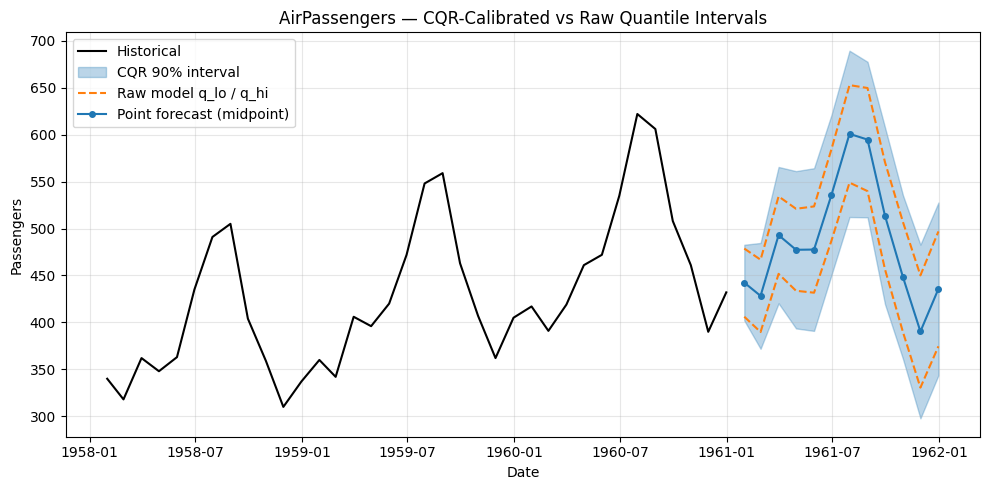

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

# Recent history
hist_dates = df["ds"].values
ax.plot(hist_dates[-36:], full_panel[0, -36:], color="black", label="Historical")

# CQR-calibrated interval
ax.fill_between(
    forecast_dates,
    result.interval[0, 0, :, 0],
    result.interval[0, 0, :, 1],
    alpha=0.30,
    color="tab:blue",
    label=f"CQR {1 - ALPHA:.0%} interval",
)

# Raw uncalibrated quantile interval (from the model alone)
ax.plot(forecast_dates, raw_lo, color="tab:orange", linestyle="--", label="Raw model q_lo / q_hi")
ax.plot(forecast_dates, raw_hi, color="tab:orange", linestyle="--")

# Point forecast (interval midpoint)
ax.plot(
    forecast_dates,
    result.point[0, 0],
    color="tab:blue",
    marker="o",
    markersize=4,
    label="Point forecast (midpoint)",
)

ax.set_title("AirPassengers — CQR-Calibrated vs Raw Quantile Intervals")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## What to take away

- CQR's interval shape mirrors the underlying model's quantile predictions
  — wider where the model is uncertain (further into the horizon, around
  seasonal peaks), narrower elsewhere.
- The CQR correction is a per-`(series, horizon)` shift of the raw
  quantile bounds. If the underlying quantile model is well calibrated,
  the correction is small. If not, CQR re-centers the interval onto the
  empirical residual quantile.
- For datasets where a quantile-aware model is overkill or unavailable,
  `SplitConformal` with `AbsoluteResidual` is the simpler alternative —
  it produces symmetric intervals around a point forecast.